In [1]:
import jax.numpy as jnp

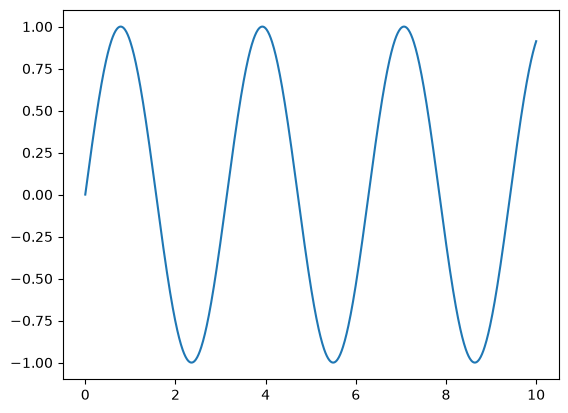

In [4]:
import matplotlib.pyplot as plt

x = jnp.linspace(0, 10, 1000)
y = 2 * jnp.sin(x) * jnp.cos(x)
plt.plot(x,y)

In [7]:
import numpy as np

x_np = np.linspace(0, 10, 1000)
x_jnp = jnp.linspace(0, 10, 1000)
print(type(x_np))
print(type(x_jnp))

<class 'numpy.ndarray'>
<class 'jaxlib._jax.ArrayImpl'>


In [ ]:
# duck-typing: can typically use np/jnp arrays interchangably
# exception: numpy arrays can be mutable, but jax arrays are immutable.

def normalize(x):
    return (x - x.mean()) / x.std()

a = np.array([1.0, 2.0, 3.0])
b = jnp.array([1.0, 2.0, 3.0])

print(normalize(a))
print(normalize(b))

[-1.22474487  0.          1.22474487]
[-1.2247448  0.         1.2247448]


In [11]:
x = jnp.arange(10)

y = x.at[0].set(10)
print(y)
print(x)

[10  1  2  3  4  5  6  7  8  9]
[0 1 2 3 4 5 6 7 8 9]


In [12]:
from jax import jit

def norm(X):
    X = X - X.mean(0)
    return X / X.std(0)

norm_compiled = jit(norm)

In [ ]:
np.random.seed(1701)
X = jnp.array(np.random.rand(10000, 10))

%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

# Note: jit can only be applied when the array sizes are static (known at compilation time)

96.7 μs ± 2.3 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
77.2 μs ± 1.14 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [15]:
from jax import grad

def sum_logistic(x):
    return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

x_small = jnp.arange(3.)
grad_fn = grad(sum_logistic)
print(grad_fn(x_small))

[0.25       0.19661197 0.10499357]


In [19]:
f1 = jit(grad(jit(sum_logistic)))
f2 = grad(jit(sum_logistic))
f3 = jit(grad(sum_logistic))
f4 = grad(sum_logistic)

%timeit f1(x_small).block_until_ready()
%timeit f2(x_small).block_until_ready()
%timeit f3(x_small).block_until_ready()
%timeit f4(x_small).block_until_ready()

2.2 μs ± 14.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
180 μs ± 2.15 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
2.21 μs ± 44 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
405 μs ± 4.51 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
